# サッカー試合結果の予測可能性の検証

European Soccer Database を用いて，機械学習モデルによる試合結果（勝/分/負）の予測精度を検証し，
サッカーという競技の本質的な予測困難性を定量的に分析する．

## 0. ライブラリのインポート

In [3]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, log_loss, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

## 1. データの読み込み

kagglehub を使って自動でデータセットをダウンロードする．
初回実行時は Kaggle の認証が必要（`~/.kaggle/kaggle.json` を配置するか，`kaggle.json` をColabにアップロードすること）．

In [4]:
import kagglehub
import os

path = kagglehub.dataset_download("hugomathien/soccer")
print("Path to dataset files:", path)

db_path = os.path.join(path, "database.sqlite")
conn = sqlite3.connect(db_path)

match = pd.read_sql('SELECT * FROM Match', conn)
league = pd.read_sql('SELECT * FROM League', conn)
team = pd.read_sql('SELECT * FROM Team', conn)
player_attr = pd.read_sql(
    'SELECT player_api_id, date, overall_rating FROM Player_Attributes', conn
)

conn.close()

print(f'Matches: {len(match)}')
print(f'Leagues: {league.shape[0]}')
print(f'Player attribute records: {len(player_attr)}')
match.head()

Using Colab cache for faster access to the 'soccer' dataset.
Path to dataset files: /kaggle/input/soccer
Matches: 25979
Leagues: 11
Player attribute records: 183978


,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,...,SJA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA
0,1,1,1,2008/2009,1,2008-08-17 00:00:00,492473,9987,9993,1,...,4.00,1.65,3.40,4.50,1.78,3.25,4.00,1.73,3.40,4.20
1,2,1,1,2008/2009,1,2008-08-16 00:00:00,492474,10000,9994,0,...,3.80,2.00,3.25,3.25,1.85,3.25,3.75,1.91,3.25,3.60
2,3,1,1,2008/2009,1,2008-08-16 00:00:00,492475,9984,8635,0,...,2.50,2.35,3.25,2.65,2.50,3.20,2.50,2.30,3.20,2.75
3,4,1,1,2008/2009,1,2008-08-17 00:00:00,492476,9991,9998,5,...,7.50,1.45,3.75,6.50,1.50,3.75,5.50,1.44,3.75,6.50
4,5,1,1,2008/2009,1,2008-08-16 00:00:00,492477,7947,9985,1,...,1.73,4.50,3.40,1.65,4.50,3.50,1.65,4.75,3.30,1.67


## 2. 前処理

### 2.1 試合結果ラベルの付与

result
H    11917
A     7466
D     6596
Name: count, dtype: int64


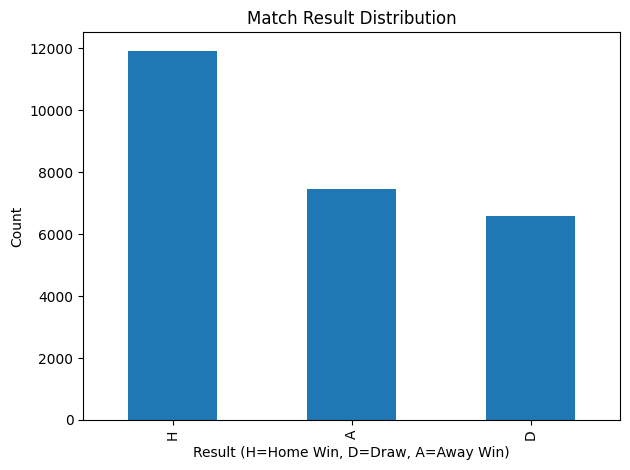

In [5]:
match = match.dropna(subset=['home_team_goal', 'away_team_goal']).copy()

def get_result(row):
    if row['home_team_goal'] > row['away_team_goal']:
        return 'H'  # Home win
    elif row['home_team_goal'] < row['away_team_goal']:
        return 'A'  # Away win
    else:
        return 'D'  # Draw

match['result'] = match.apply(get_result, axis=1)
print(match['result'].value_counts())
match['result'].value_counts().plot(kind='bar', title='Match Result Distribution')
plt.xlabel('Result (H=Home Win, D=Draw, A=Away Win)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('result_distribution.pdf', bbox_inches='tight')
plt.show()

### 2.2 直近 n 試合の移動平均による特徴量設計

各試合の直前 n 試合における統計量（平均得点・失点・勝点）を特徴量として使用する．
これによりチームの「直近の調子」を数値化する．

In [6]:
WINDOW = 5  # Number of recent matches to use

match = match.sort_values('date').reset_index(drop=True)

def compute_team_stats(df, team_id_col, goal_for_col, goal_against_col, prefix):
    """Compute rolling stats over the last WINDOW matches for each team."""
    records = []
    for _, row in df.iterrows():
        tid = row[team_id_col]
        date = row['date']
        past = df[(df[team_id_col] == tid) & (df['date'] < date)].tail(WINDOW)
        if len(past) < WINDOW:
            records.append({f'{prefix}_avg_gf': np.nan,
                            f'{prefix}_avg_ga': np.nan,
                            f'{prefix}_avg_pts': np.nan})
        else:
            gf = past[goal_for_col].mean()
            ga = past[goal_against_col].mean()
            pts = past['result'].map({'H': 3 if prefix == 'home' else 0,
                                      'A': 0 if prefix == 'home' else 3,
                                      'D': 1}).mean()
            records.append({f'{prefix}_avg_gf': gf,
                            f'{prefix}_avg_ga': ga,
                            f'{prefix}_avg_pts': pts})
    return pd.DataFrame(records)

home_stats = compute_team_stats(match, 'home_team_api_id', 'home_team_goal', 'away_team_goal', 'home')
away_stats = compute_team_stats(match, 'away_team_api_id', 'away_team_goal', 'home_team_goal', 'away')

match = pd.concat([match.reset_index(drop=True), home_stats, away_stats], axis=1)
match = match.dropna(subset=['home_avg_gf', 'away_avg_gf', 'B365H', 'B365D', 'B365A'])

print(f'Matches after feature engineering: {len(match)}')
match[['home_avg_gf', 'home_avg_ga', 'home_avg_pts',
       'away_avg_gf', 'away_avg_ga', 'away_avg_pts',
       'B365H', 'B365D', 'B365A']].describe()

Matches after feature engineering: 20817


,home_avg_gf,home_avg_ga,home_avg_pts,away_avg_gf,away_avg_ga,away_avg_pts,B365H,B365D,B365A
count,20817.000000,20817.000000,20817.000000,20817.000000,20817.000000,20817.000000,20817.000000,20817.000000,20817.000000
mean,1.558582,1.156872,1.642907,1.172484,1.541077,1.126243,2.635427,3.852059,4.666117
std,0.709614,0.554440,0.685537,0.596006,0.638750,0.654611,1.806291,1.128272,3.741810
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.040000,1.400000,1.080000
25%,1.000000,0.800000,1.200000,0.800000,1.000000,0.600000,1.670000,3.300000,2.500000
50%,1.400000,1.200000,1.600000,1.000000,1.400000,1.000000,2.100000,3.500000,3.500000
75%,2.000000,1.600000,2.200000,1.600000,2.000000,1.600000,2.800000,4.000000,5.250000
max,5.800000,4.000000,3.000000,4.800000,4.600000,3.000000,26.000000,17.000000,51.000000


### 2.3 スタメン平均レーティングの算出

Player_Attributes テーブルには EA Sports FIFA の `overall_rating`（1〜99）が記録されている．
各試合の出場選手11人について，試合日以前の最新レーティングを取得して平均し，
チームの「絶対的な戦力」を表す特徴量として使用する．

In [7]:
home_player_cols = [f'home_player_{i}' for i in range(1, 12)]
away_player_cols = [f'away_player_{i}' for i in range(1, 12)]

# Parse dates in player_attr
player_attr['date'] = pd.to_datetime(player_attr['date'], errors='coerce')
player_attr_clean = (player_attr
                     .dropna(subset=['overall_rating', 'date'])
                     .copy())
player_attr_clean['player_api_id'] = pd.to_numeric(player_attr_clean['player_api_id'], errors='coerce')
player_attr_clean = player_attr_clean.dropna(subset=['player_api_id'])
player_attr_clean['player_api_id'] = player_attr_clean['player_api_id'].astype(int)
player_attr_clean = player_attr_clean.sort_values(['player_api_id', 'date'])

match['date_dt'] = pd.to_datetime(match['date'], errors='coerce')

# Pre-build lookup dict for fast access: pid -> list of (date, rating) sorted by date
from collections import defaultdict
rating_lookup = defaultdict(list)
for _, row in player_attr_clean.iterrows():
    rating_lookup[row['player_api_id']].append((row['date'], row['overall_rating']))

def get_rating_at_date(pid, match_date):
    """Return the most recent FIFA overall_rating for a player before match_date."""
    if pd.isna(pid):
        return np.nan
    try:
        pid_int = int(pid)
    except (ValueError, TypeError):
        return np.nan
    records = rating_lookup.get(pid_int, [])
    valid = [r for d, r in records if d <= match_date]
    return valid[-1] if valid else np.nan

def compute_team_avg_rating(row, player_cols):
    """Average FIFA rating of the starting XI at match time."""
    match_date = row['date_dt']
    ratings = []
    for col in player_cols:
        pid = row.get(col, np.nan)
        if not pd.isna(pid):
            r = get_rating_at_date(pid, match_date)
            if not np.isnan(r):
                ratings.append(r)
    return np.mean(ratings) if ratings else np.nan

print('Computing home team avg ratings...')
match['home_avg_rating'] = match.apply(
    lambda r: compute_team_avg_rating(r, home_player_cols), axis=1)
print('Computing away team avg ratings...')
match['away_avg_rating'] = match.apply(
    lambda r: compute_team_avg_rating(r, away_player_cols), axis=1)

match = match.dropna(subset=['home_avg_rating', 'away_avg_rating'])
print(f'Matches after adding player ratings: {len(match)}')
match[['home_avg_rating', 'away_avg_rating']].describe()

Computing home team avg ratings...
Computing away team avg ratings...
Matches after adding player ratings: 20533


,home_avg_rating,away_avg_rating
count,20533.000000,20533.000000
mean,72.203573,72.125237
std,5.262744,5.262050
min,57.500000,57.800000
25%,68.454545,68.400000
50%,72.545455,72.454545
75%,75.636364,75.545455
max,86.636364,87.272727


## 3. モデルの学習と評価

### 3.1 データの分割

In [8]:
from sklearn.preprocessing import LabelEncoder

FEATURES = [
    'home_avg_gf', 'home_avg_ga', 'home_avg_pts',
    'away_avg_gf', 'away_avg_ga', 'away_avg_pts',
    'B365H', 'B365D', 'B365A',            # Bet365 odds (encodes market's probability estimate)
    'home_avg_rating', 'away_avg_rating',  # FIFA overall rating of starting XI
]
LABEL = 'result'

X = match[FEATURES].values
y = match[LABEL].values

# Encode string labels to integers for XGBoost ('A'->0, 'D'->1, 'H'->2)
le = LabelEncoder()
y_enc = le.fit_transform(y)  # 'A'->0, 'D'->1, 'H'->2

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# Keep string versions for baselines and human-readable evaluation
y_test_str = le.inverse_transform(y_test)
y_train_str = le.inverse_transform(y_train)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f'Train: {len(X_train)} matches / Test: {len(X_test)} matches')
print(f'Classes: {le.classes_}  (encoded as {list(range(len(le.classes_)))})')
print(f'Features ({len(FEATURES)}): {FEATURES}')

Train: 16426 matches / Test: 4107 matches
Classes: ['A' 'D' 'H']  (encoded as [0, 1, 2])
Features (11): ['home_avg_gf', 'home_avg_ga', 'home_avg_pts', 'away_avg_gf', 'away_avg_ga', 'away_avg_pts', 'B365H', 'B365D', 'B365A', 'home_avg_rating', 'away_avg_rating']


### 3.2 ベースラインの設定

比較対象として，以下の単純なベースラインを定義する．

- **常にホーム勝利を予測**: ホームアドバンテージのみを利用
- **ランダム予測**: 各クラスを均等確率で予測

In [9]:
# Always predict home win
y_pred_home = np.array(['H'] * len(y_test_str))
acc_home = accuracy_score(y_test_str, y_pred_home)

# Random prediction baseline
np.random.seed(42)
y_pred_random = np.random.choice(['H', 'D', 'A'], size=len(y_test_str))
acc_random = accuracy_score(y_test_str, y_pred_random)

print(f'Home Win Baseline: {acc_home:.3f}')
print(f'Random Baseline:   {acc_random:.3f}')

Home Win Baseline: 0.459
Random Baseline:   0.323


### 3.3 各モデルの学習・評価

In [10]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='mlogloss', verbosity=0),
}

results = {}

for name, model in models.items():
    X_tr = X_train_sc if name == 'Logistic Regression' else X_train
    X_te = X_test_sc  if name == 'Logistic Regression' else X_test
    model.fit(X_tr, y_train)
    y_pred_enc = model.predict(X_te)
    y_prob = model.predict_proba(X_te)
    # Decode numeric predictions back to string labels for evaluation
    y_pred_str = le.inverse_transform(y_pred_enc)
    acc = accuracy_score(y_test_str, y_pred_str)
    ll  = log_loss(y_test_str, y_prob)
    results[name] = {'model': model, 'y_pred': y_pred_str, 'acc': acc, 'log_loss': ll}
    print(f'{name}: Accuracy={acc:.3f}, LogLoss={ll:.3f}')

Logistic Regression: Accuracy=0.537, LogLoss=0.971
Random Forest: Accuracy=0.507, LogLoss=1.016
XGBoost: Accuracy=0.500, LogLoss=1.016


### 3.4 過学習の検証

訓練データとテストデータの精度を比較し，過学習の有無を確認する．

In [16]:
overfitting_rows = []

for name, res in results.items():
    X_tr = X_train_sc if name == 'Logistic Regression' else X_train
    X_te = X_test_sc  if name == 'Logistic Regression' else X_test
    model = res['model']

    acc_train = accuracy_score(y_train_str, le.inverse_transform(model.predict(X_tr)))
    acc_test  = res['acc']
    overfitting_rows.append({
        'Model': name,
        'Train Accuracy': acc_train,
        'Test Accuracy':  acc_test,
        'Gap (Train - Test)': acc_train - acc_test,
    })

overfit_df = pd.DataFrame(overfitting_rows).set_index('Model')
print(overfit_df.to_string(float_format='{:.3f}'.format))

                     Train Accuracy  Test Accuracy  Gap (Train - Test)
Model                                                                 
Logistic Regression           0.532          0.537              -0.005
Random Forest                 1.000          0.507               0.493
XGBoost                       0.741          0.500               0.241


## 4. 結果の可視化

### 4.1 精度の比較

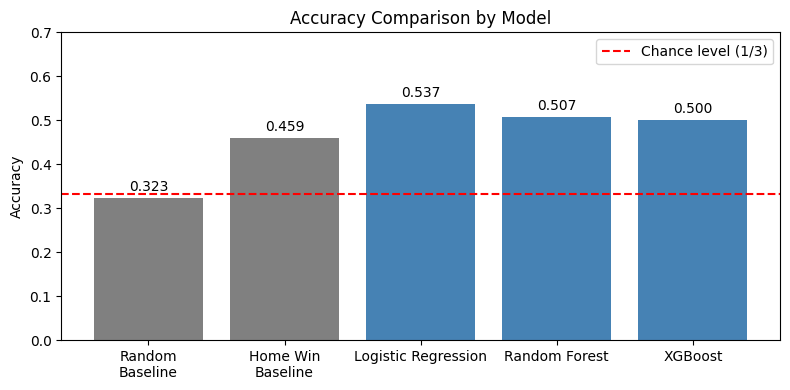

In [12]:
labels = ['Random\nBaseline', 'Home Win\nBaseline'] + list(models.keys())
accs   = [acc_random, acc_home] + [results[m]['acc'] for m in models]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, accs, color=['gray', 'gray', 'steelblue', 'steelblue', 'steelblue'])
ax.axhline(1/3, color='red', linestyle='--', label='Chance level (1/3)')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy Comparison by Model')
ax.set_ylim(0, 0.7)
ax.legend()
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.3f}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('accuracy_comparison.pdf', bbox_inches='tight')
plt.show()

### 4.2 混同行列（XGBoost）

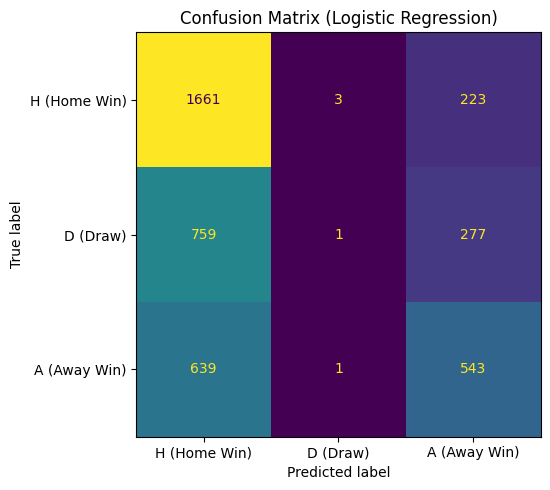

              precision    recall  f1-score   support

           H       0.52      0.46      0.49      1183
           D       0.20      0.00      0.00      1037
           A       0.54      0.88      0.67      1887

    accuracy                           0.54      4107
   macro avg       0.42      0.45      0.39      4107
weighted avg       0.45      0.54      0.45      4107



In [13]:
best_name = max(results, key=lambda k: results[k]['acc'])
y_pred_best = results[best_name]['y_pred']  # already decoded to string labels

cm = confusion_matrix(y_test_str, y_pred_best, labels=['H', 'D', 'A'])
disp = ConfusionMatrixDisplay(cm, display_labels=['H (Home Win)', 'D (Draw)', 'A (Away Win)'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False)
ax.set_title(f'Confusion Matrix ({best_name})')
plt.tight_layout()
plt.savefig('confusion_matrix.pdf', bbox_inches='tight')
plt.show()

print(classification_report(y_test_str, y_pred_best, target_names=['H', 'D', 'A']))

### 4.3 特徴量重要度（Random Forest）

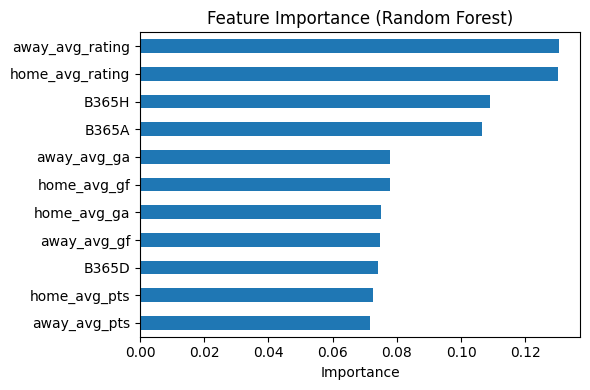

In [14]:
rf = results['Random Forest']['model']
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(6, 4))
importances.plot(kind='barh', ax=ax)
ax.set_title('Feature Importance (Random Forest)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.pdf', bbox_inches='tight')
plt.show()

## 5. 番狂わせの分析

「直近の調子」から見て大きな戦力差があるにもかかわらず，予測が外れた試合（番狂わせ）の割合を分析する．

/tmp/ipykernel_1536/1003389255.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  accuracy_by_gap = test_df.groupby('pts_diff_bin')['correct'].mean()


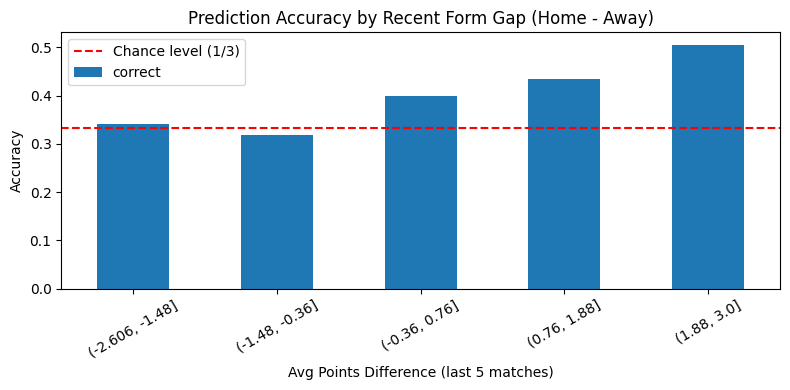

In [15]:
test_df = match.iloc[-len(y_test_str):].copy().reset_index(drop=True)
test_df['y_pred'] = results[best_name]['y_pred']  # string labels
test_df['correct'] = test_df['result'] == test_df['y_pred']

# Define "form gap" as difference in recent average points (home - away)
test_df['pts_diff'] = test_df['home_avg_pts'] - test_df['away_avg_pts']
test_df['pts_diff_bin'] = pd.cut(test_df['pts_diff'], bins=5)

accuracy_by_gap = test_df.groupby('pts_diff_bin')['correct'].mean()

fig, ax = plt.subplots(figsize=(8, 4))
accuracy_by_gap.plot(kind='bar', ax=ax)
ax.set_title('Prediction Accuracy by Recent Form Gap (Home - Away)')
ax.set_xlabel('Avg Points Difference (last 5 matches)')
ax.set_ylabel('Accuracy')
ax.axhline(1/3, color='red', linestyle='--', label='Chance level (1/3)')
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('upset_analysis.pdf', bbox_inches='tight')
plt.show()

## 6. 考察のまとめ（メモ）

ここに考察のポイントをメモしていく．

- 全モデルの精度はどの程度だったか？ベースラインとの差は？
- 引き分けのF1スコアが特に低い場合，その理由は？
- 戦力差が大きい試合でも予測が外れる割合は？
- 「低得点競技としてのサッカー」という競技特性との関連